In [1]:
import os

import random
import numpy as np
import torch
from models.checkpointing import create_model, load_model_state
from QUTCC_eval import plot_vis_slider, skeletonize
from train import get_dataloaders, get_transform
from omegaconf import OmegaConf
import json
from skimage.filters import threshold_otsu

np.random.seed(0)
random.seed(0)
torch.manual_seed(0)
print(torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

%matplotlib inline
%load_ext autoreload
%autoreload 2

/home/bl788/.conda/envs/qutcc2/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/bl788/.conda/envs/qutcc2/lib/python3.13/site-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an 

True
Device: cuda


In [2]:
#Load in weights + calibration values
im2im_deep_folder = "experiments/mri/im2im_deep_epochs50_bs12_2025-10-18-14.18.46"

qutcc_folder = "experiments/mri/qutcc_epochs50_bs12_2025-10-18-10.07.36"

im2im_ckpt = os.path.join(im2im_deep_folder, 'checkpoints', 'epoch10.pth')
qutcc_ckpt = os.path.join(qutcc_folder, 'checkpoints', 'epoch10.pth')

# load jsons from the directories
with open(os.path.join(qutcc_folder, 'analysis', 'quantile_qs_epoch_5.json'), 'r') as f:
    qutcc_config = json.load(f)

# extracted this manually as the error bound was too high despite running for 10 epochs and failed to calculate bound
im2im_deep_lambda = 1.0110
upper_q = float(qutcc_config['upper_q'])
lower_q = float(qutcc_config['lower_q'])

im2im_deep = create_model(net = "im2im_deep", device = device)
im2im_deep = load_model_state(im2im_deep, im2im_ckpt, device)

qutcc = create_model(net = "qutcc", device = device)
qutcc = load_model_state(qutcc, qutcc_ckpt, device)

Model state loaded from experiments/mri/im2im_deep_epochs50_bs12_2025-10-18-14.18.46/checkpoints/epoch10.pth
Model state loaded from experiments/mri/qutcc_epochs50_bs12_2025-10-18-10.07.36/checkpoints/epoch10.pth


In [3]:
args = OmegaConf.create({
    "net": "im2im_deep",
    "transform": "center_crop",
    "epochs": 50,
    "experiment_type": "MRI",
    "data_root": "/share/monakhova/Cassandra_data/UQNet_proj/Fast_MRI/RAW_singlecoil_train",
    "in_channels": 1,
    "noise_type": "poisson",
    "sigma": 0.75,
    "batch_size": 12,
    "exp_name": "mri",
    "ckpt_freq": 2
})

_, test_loader = get_dataloaders(args, get_transform(args))

loading dataset from /share/monakhova/Cassandra_data/UQNet_proj/Fast_MRI/RAW_singlecoil_train/training...
Loading 644 volumes...


Using 22838 total slices
Experiment type: MRI | Train dataset size: 20554 | Test dataset size: 2284


In [4]:
a = iter(test_loader)

noisy dims torch.Size([12, 1, 320, 320])
Image min: 0.00015017782 max: 1.0


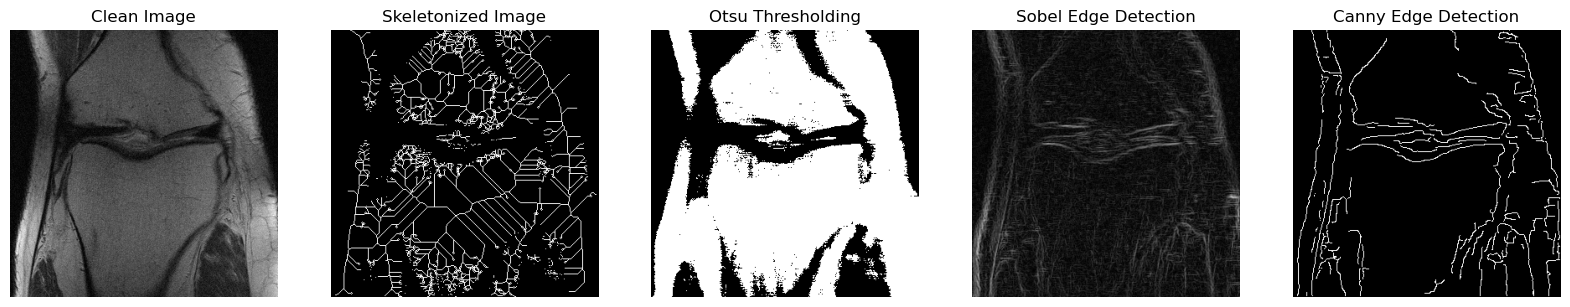

In [17]:
noisy, clean = next(a)
print("noisy dims", noisy.shape) # torch.Size([12, 1, 320, 320])
batch_idx = 0
noisy_sample = noisy[batch_idx].cpu().numpy().squeeze()
clean_sample = clean[batch_idx].cpu().numpy().squeeze()


# try skeletonization, other edge detection algorithms
img = skeletonize(noisy_sample, threshold=0.3)
# create a 1x4 plot to compare clean input, skeletonized version, otsu thresholded version, sobel edge detection, canny edge detection
otsu_thresh = threshold_otsu(noisy_sample)
otsu_img = noisy_sample > otsu_thresh
from skimage.filters import sobel
sobel_img = sobel(noisy_sample)

# apply canny edge detection
from skimage.feature import canny
canny_img = canny(noisy_sample, sigma=1.5)


import matplotlib.pyplot as plt
fig, axs = plt.subplots(1, 5, figsize=(20, 5))
axs[0].imshow(clean_sample, cmap='gray')
axs[0].set_title('Clean Image')
axs[1].imshow(img, cmap='gray')
axs[1].set_title('Skeletonized Image')
axs[2].imshow(otsu_img, cmap='gray')
axs[2].set_title('Otsu Thresholding')
axs[3].imshow(sobel_img, cmap='gray')
axs[3].set_title('Sobel Edge Detection')
axs[4].imshow(canny_img, cmap='gray')
axs[4].set_title('Canny Edge Detection')
for ax in axs:
    ax.axis('off')
plt.show()

In [18]:
#Visualization
plot_vis_slider(dataloader=test_loader, im2im_model=im2im_deep, 
                    quantile_model=qutcc, im2im_lam=im2im_deep_lambda, lower_q=lower_q, upper_q=upper_q, 
                    device=device, exp_type="exp", save=False)

Loading images from dataloader...
Loaded 2284 images from dataloader
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/home/bl788/.conda/envs/qutcc2/lib/python3.13/site-packages/torchmetrics/utilities/prints.py:62: FutureWarning: Importing `StructuralSimilarityIndexMeasure` from `torchmetrics` was deprecated and will be removed in 2.0. Import `StructuralSimilarityIndexMeasure` from `torchmetrics.image` instead.
  _future_warning(
/home/bl788/.conda/envs/qutcc2/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bl788/.conda/envs/qutcc2/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /home/bl788/.conda/envs/qutcc2/lib/python3.13/site-packages/lpips/weights/v0.1/vgg.pth


interactive(children=(IntSlider(value=0, continuous_update=False, description='Image:', max=2283), Output()), …

<function QUTCC_eval.plot_vis_slider.<locals>.plot_for_index(index)>